### EEG Signal Exploration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mne
from sklearn.cluster import KMeans
print("Finished importing libraries")

Finished importing libraries


In [3]:
# Load the dataset
raw = mne.io.read_raw_brainvision(
   "sub-00063_ses-2_task-sleep_acq-20170223T0434.vhdr",
    preload=True
)

Extracting parameters from sub-00063_ses-2_task-sleep_acq-20170223T0434.vhdr...
Setting channel info structure...


C:\Users\hp\AppData\Local\Temp\ipykernel_3576\3842733681.py:2: RuntimeWarning: No coordinate information found for channels ['ECG', 'EMG']. Setting channel types to misc. To avoid this warning, set channel types explicitly.
  raw = mne.io.read_raw_brainvision(


Reading 0 ... 1934429  =      0.000 ...  7737.716 secs...


C:\Users\hp\AppData\Local\Temp\ipykernel_3576\3842733681.py:2: RuntimeWarning: Not setting positions of 2 misc channels found in montage:
['ECG', 'EMG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_brainvision(


In [4]:
print("Sampling rate", raw.info['sfreq'])        # sampling rate (how many readings per second)
print("Total number of samples", len(raw.times))           # total number of samples
print("Total duration", raw.times[-1], 'seconds') # total duration
seconds = raw.times[-1]
# Get hours and remaining seconds
hours, remainder = divmod(seconds, 3600)
# Get minutes and final seconds
minutes, seconds = divmod(remainder, 60)

print(f"Total Duration:{int(hours)} hours, {int(minutes)} minutes, {seconds:.2f} seconds")

Sampling rate 250.0
Total number of samples 1934430
Total duration 7737.716 seconds
Total Duration:2 hours, 8 minutes, 57.72 seconds


#### Visualizing the data

Using matplotlib as 2D backend.


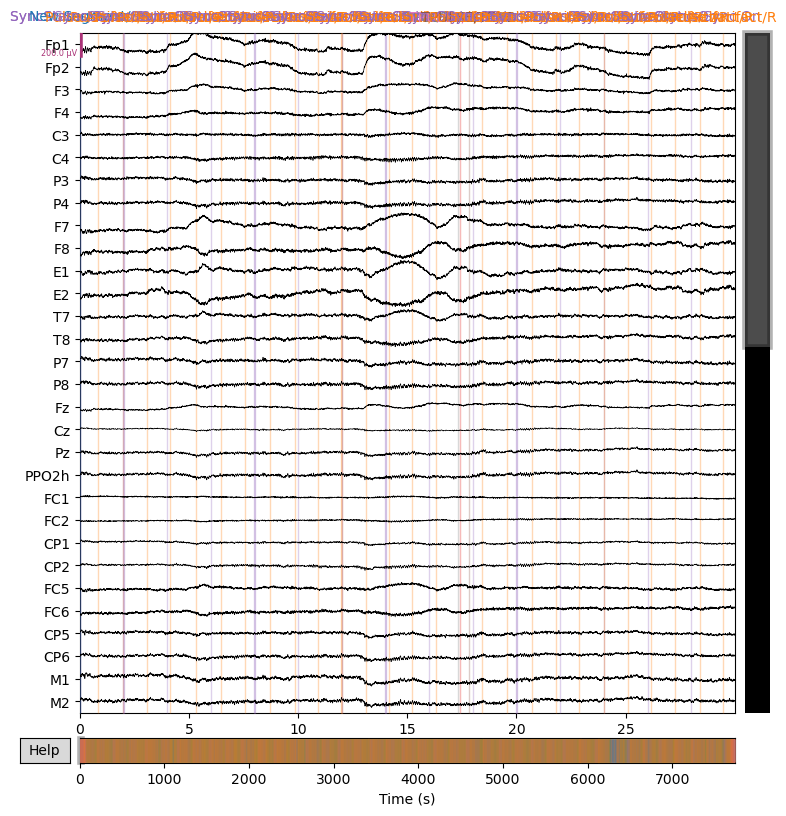

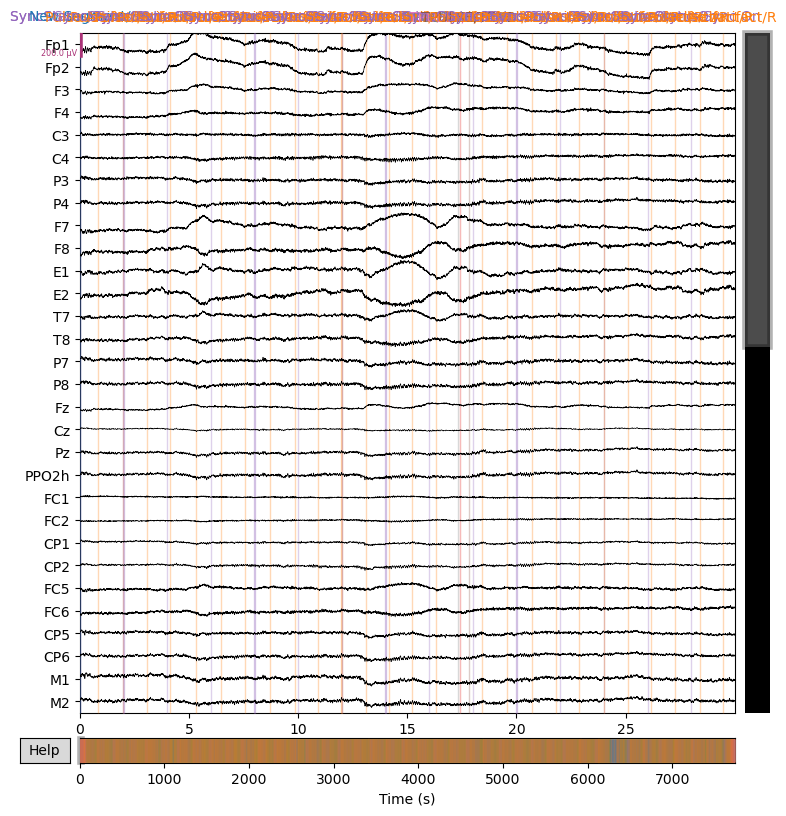

In [5]:
raw.plot(n_channels=30, duration=30, scalings=dict(eeg=100e-6))

#### Setting the channel types because in an eeg ecording data there are a lot of artifacts and noise that we do not need interfering with our processing

In [7]:
channel_types = {
    'ECG': 'ecg',
    'EMG': 'emg', 
    'E1': 'eog',
    'E2': 'eog',
    'M1': 'misc',
    'M2': 'misc'
}
raw.set_channel_types(channel_types)

C:\Users\hp\AppData\Local\Temp\ipykernel_3576\4119409638.py:9: RuntimeWarning: The unit for channel(s) M1, M2 has changed from V to NA.
  raw.set_channel_types(channel_types)


<RawBrainVision | sub-00063_ses-2_task-sleep_acq-20170223T0434_eeg.eeg, 65 x 1934430 (7737.7 s), ~959.4 MiB, data loaded>

In [8]:
raw.notch_filter(freqs=50) # this removes electrical interference, the  average in most countries is 50

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1651 samples (6.604 s)



<RawBrainVision | sub-00063_ses-2_task-sleep_acq-20170223T0434_eeg.eeg, 65 x 1934430 (7737.7 s), ~959.4 MiB, data loaded>

In [9]:
raw.filter(l_freq= 0.5, h_freq= 40) # this removes anything lower than 0.5 and higher than 40 from the data because sleep data is mostly withinn there

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (6.604 s)



<RawBrainVision | sub-00063_ses-2_task-sleep_acq-20170223T0434_eeg.eeg, 65 x 1934430 (7737.7 s), ~959.4 MiB, data loaded>

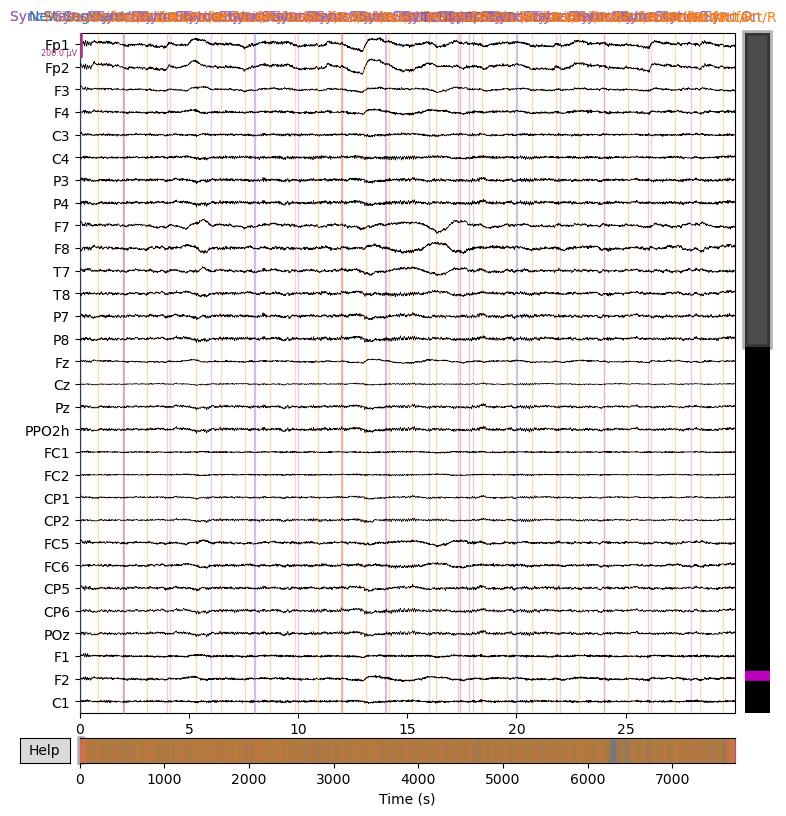

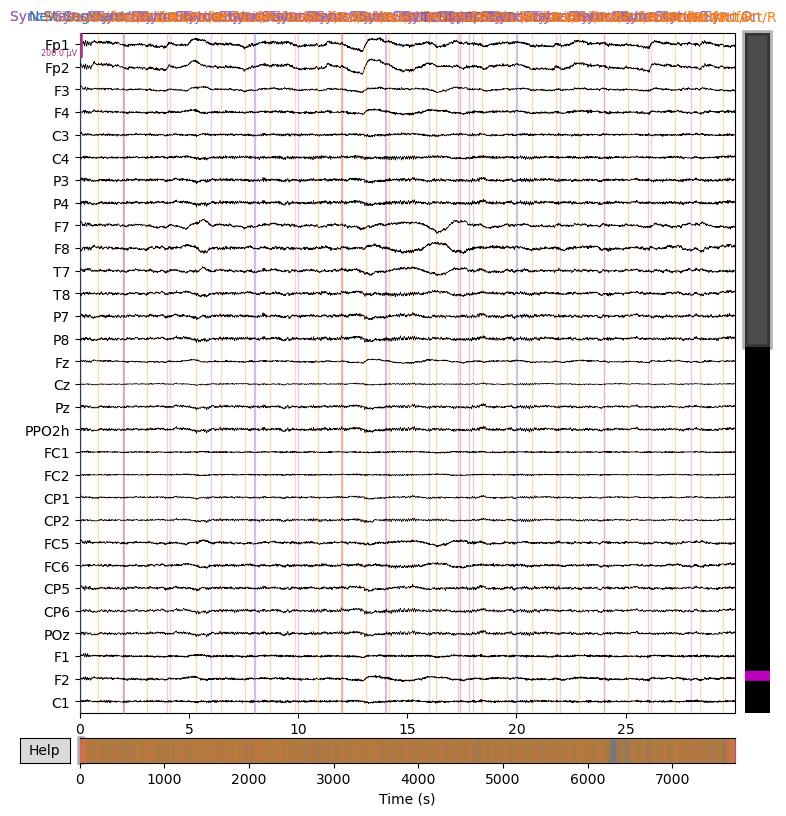

In [10]:
raw.plot(n_channels=30, duration=30, scalings=dict(eeg=100e-6))

In [11]:
raw.info['bads'] = ['Cz', 'FC1', 'FC2', 'CP1']  # ignoring the bad channels that dont just fit
print(raw.ch_names)

['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'F7', 'F8', 'E1', 'E2', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz', 'PPO2h', 'FC1', 'FC2', 'CP1', 'CP2', 'FC5', 'FC6', 'CP5', 'CP6', 'M1', 'M2', 'POz', 'ECG', 'F1', 'F2', 'C1', 'C2', 'P1', 'P2', 'AF3', 'AF4', 'FC3', 'FC4', 'CP3', 'CP4', 'PO3', 'PO4', 'F5', 'F6', 'C5', 'C6', 'P5', 'P6', 'AF7', 'AF8', 'FT7', 'FT8', 'TP7', 'TP8', 'PO7', 'PO8', 'FT9', 'FT10', 'Fpz', 'CPz', 'EMG']


#### We use this to identify brain activity, eye blinks, muscle movement and removet them from processing

In [12]:
raw_copy = raw
from mne.preprocessing import ICA

ica = ICA(n_components=25, random_state=42)
ica.fit(raw_copy)

Fitting ICA to data using 55 channels (please be patient, this may take a while)
Selecting by number: 25 components
Fitting ICA took 223.4s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,72 iterations on raw data (1934430 samples)
ICA components,25
Available PCA components,55
Channel types,eeg
ICA components marked for exclusion,—


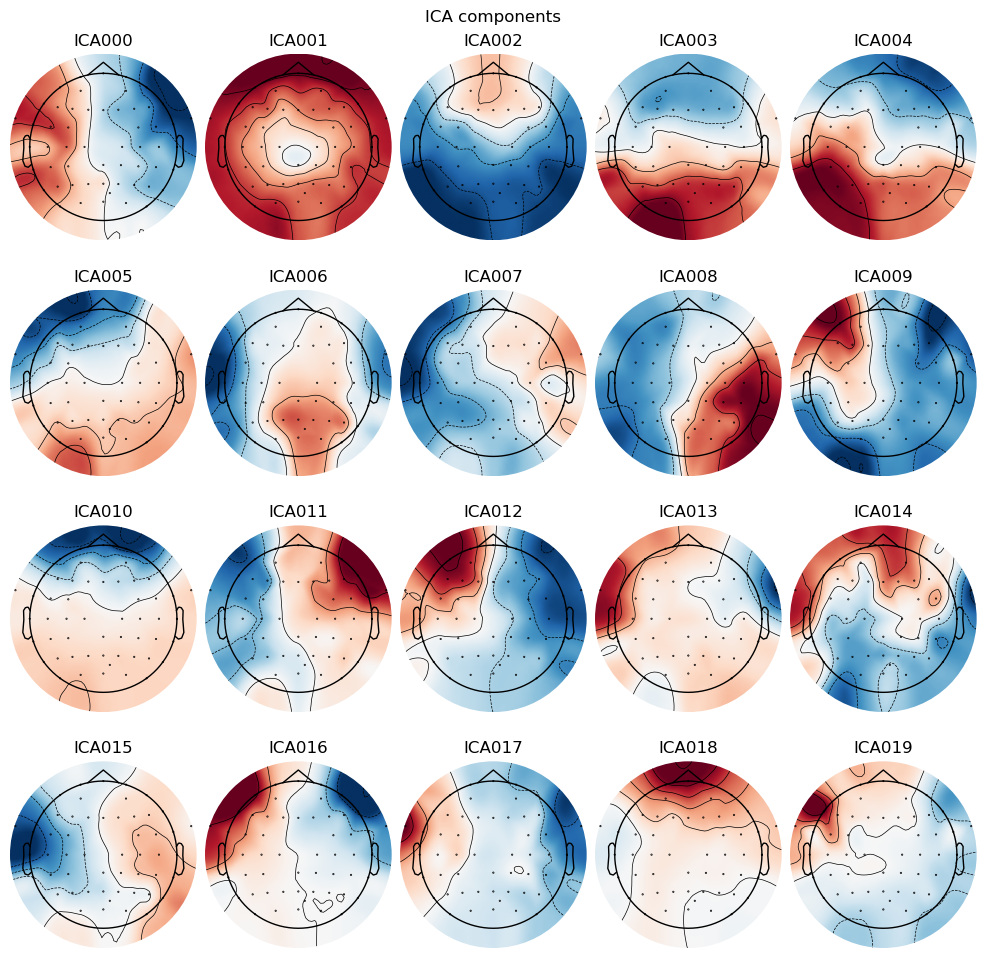

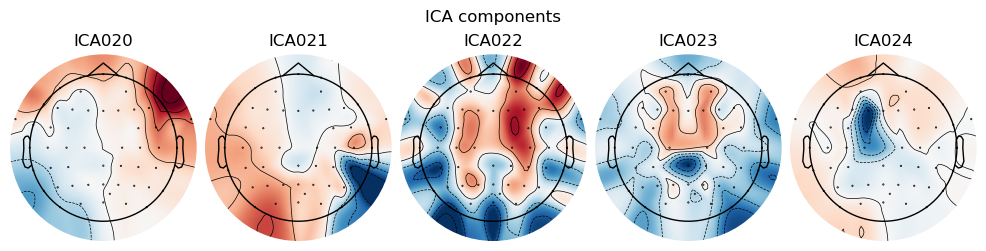

[<MNEFigure size 975x967 with 20 Axes>, <MNEFigure size 975x260.5 with 5 Axes>]

In [13]:
ica.plot_components()

#### So in our data there are eye blnks and head tilts which are not actual brain activity but got picked up by the eeg, this ica function shows us and we remove it from the preprocessing

In [14]:
ica.exclude = [0,1,3,4]
raw_clean = ica.apply(raw_copy.copy())

Applying ICA to Raw instance
    Transforming to ICA space (25 components)
    Zeroing out 4 ICA components
    Projecting back using 55 PCA components


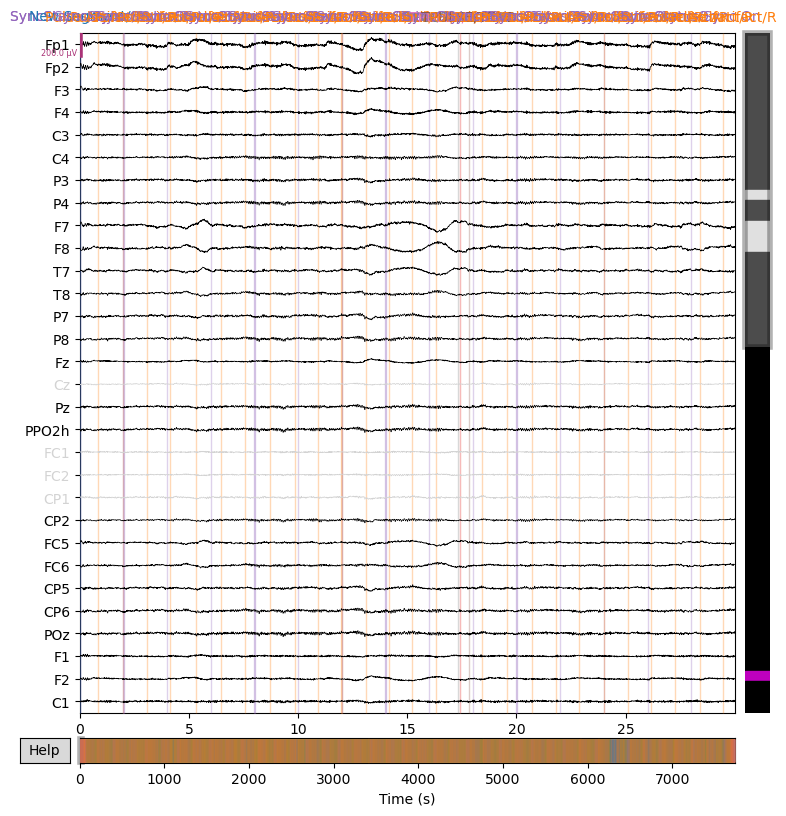

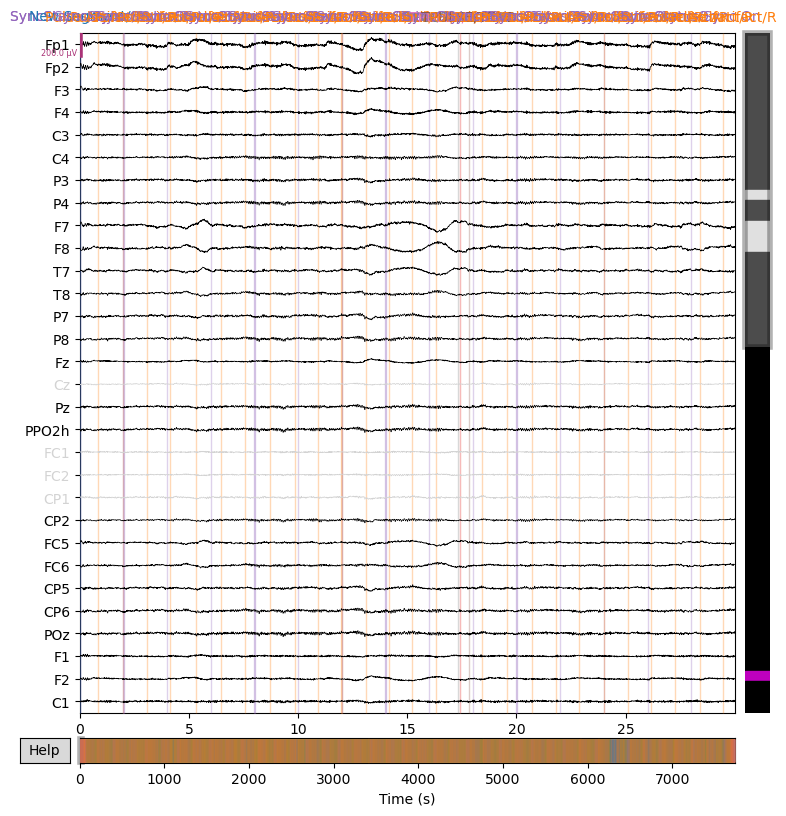

In [15]:
raw_clean.plot(n_channels=30, duration=30, scalings=dict(eeg=100e-6))

##### Now we reference the data to select the parts we want to see, i chose specific regions because they are more associated with sleep because i dont want any outliers from the different regions

In [23]:
raw.set_eeg_reference(['C3', 'C4', 'F3', 'F4'])
raw_clean.apply_proj()

EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Projections have already been applied. Setting proj attribute to True.


<RawBrainVision | sub-00063_ses-2_task-sleep_acq-20170223T0434_eeg.eeg, 65 x 1934430 (7737.7 s), ~959.4 MiB, data loaded>

#### Epoching seperates the data into 30sec pieces to analyze the chunks at dufferent points in time so we'd see whats happening at that certain time

In [24]:
from mne import make_fixed_length_epochs

epochs = make_fixed_length_epochs(raw_clean, duration=30, preload=True)
print(epochs)

Not setting metadata
257 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 257 events and 7500 original time points ...
0 bad epochs dropped
<Epochs | 257 events (all good), 0 – 29.996 s (baseline off), ~955.9 MiB, data loaded,
 '1': 257>


In [25]:
print(epochs.info)

<Info | 10 non-empty values
 bads: 4 items (Cz, FC1, FC2, CP1)
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, F7, F8, E1, E2, T7, T8, P7, ...
 chs: 59 EEG, 2 EOG, 2 misc, 1 ECG, 1 EMG
 custom_ref_applied: False
 dig: 66 items (3 Cardinal, 63 EEG)
 highpass: 0.5 Hz
 lowpass: 40.0 Hz
 meas_date: 2017-02-23 04:32:55 UTC
 nchan: 65
 projs: Average EEG reference: on
 sfreq: 250.0 Hz
>


#### Computing Power Spectral Density (PSD)
#### This step shows how much power exists in different brain wave frequencies (delta, theta, alpha, beta)

In [26]:
# frequency bands
bands = {
    'delta': (0.5, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta': (13, 30)
}

# get the sampling rate
sfreq = epochs.info['sfreq']

# calculate band power for each epoch
band_power = {band: [] for band in bands}

for epoch in epochs.get_data():
    # epoch shape is (channels, timepoints)
    for band, (low, high) in bands.items():
        # fourier transform
        fft_vals = np.abs(np.fft.rfft(epoch, axis=1)) ** 2
        freqs = np.fft.rfftfreq(epoch.shape[1], 1/sfreq)
        
        # find which frequencies fall in this band
        idx = np.where((freqs >= low) & (freqs <= high))[0]
        
        # average power across those frequencies and all channels
        power = fft_vals[:, idx].mean()
        band_power[band].append(power)


df = pd.DataFrame(band_power)
print(df.head(10))

      delta     theta     alpha      beta
0  0.000235  0.000037  0.000010  0.000002
1  0.000228  0.000036  0.000009  0.000002
2  0.000485  0.000077  0.000026  0.000028
3  0.000209  0.000033  0.000008  0.000002
4  0.000179  0.000029  0.000008  0.000002
5  0.000196  0.000035  0.000008  0.000002
6  0.000167  0.000028  0.000008  0.000002
7  0.000166  0.000032  0.000007  0.000002
8  0.000175  0.000031  0.000008  0.000002
9  0.000181  0.000034  0.000008  0.000002


#### from barely looking at the numbers we can see that the strengths at the delta band is greater than the rest which shows that the recording started from awakening and the participant went on to resting state

### The next step is plotting the graphs of the different power bands we have above

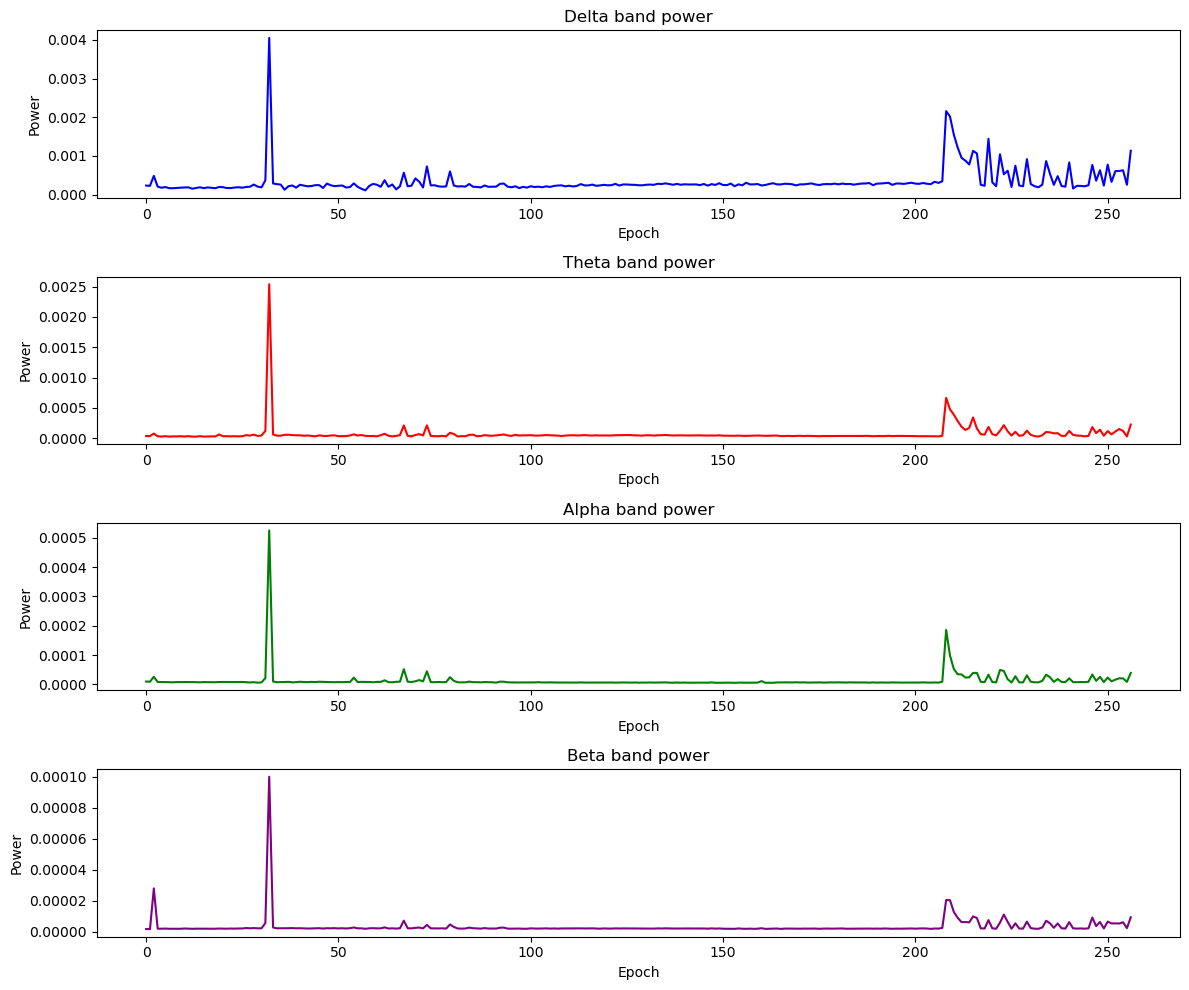

In [27]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

colors = ['blue', 'red', 'green', 'purple']

for ax, band, color in zip(axes, bands.keys(), colors):
    ax.plot(df[band], color=color)
    ax.set_title(f'{band.capitalize()} band power')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Power')

plt.tight_layout()
plt.show()

#### Still a lot of outliers in our data which is not supposed to be

In [28]:
# find epochs where any band power is suspiciously high
delta_array = np.array(band_power['delta'])
threshold = delta_array.mean() + 3 * delta_array.std()

bad_epochs = np.where(delta_array > threshold)[0]
print("Bad epochs:", bad_epochs)

Bad epochs: [ 32 208 209 210 219]


In [29]:
epochs.drop(bad_epochs)
print("Epochs remaining:", len(epochs))

Dropped 5 epochs: 32, 208, 209, 210, 219
Epochs remaining: 252


In [30]:
print("Recording duration (seconds):", raw_clean.times[-1])
print("Number of epochs:", len(epochs))
print("Sampling rate:", raw_clean.info['sfreq'])
print("Channels:", raw_clean.ch_names)

Recording duration (seconds): 7737.716
Number of epochs: 252
Sampling rate: 250.0
Channels: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'F7', 'F8', 'E1', 'E2', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz', 'PPO2h', 'FC1', 'FC2', 'CP1', 'CP2', 'FC5', 'FC6', 'CP5', 'CP6', 'M1', 'M2', 'POz', 'ECG', 'F1', 'F2', 'C1', 'C2', 'P1', 'P2', 'AF3', 'AF4', 'FC3', 'FC4', 'CP3', 'CP4', 'PO3', 'PO4', 'F5', 'F6', 'C5', 'C6', 'P5', 'P6', 'AF7', 'AF8', 'FT7', 'FT8', 'TP7', 'TP8', 'PO7', 'PO8', 'FT9', 'FT10', 'Fpz', 'CPz', 'EMG']


In [31]:
# drop non-brain channels
non_brain = ['ECG', 'EMG', 'E1', 'E2', 'M1', 'M2']
epochs.drop_channels(non_brain)
print("Channels remaining:", len(epochs.ch_names))

Channels remaining: 59


In [32]:
band_power = {band: [] for band in bands}

for epoch in epochs.get_data():
    for band, (low, high) in bands.items():
        fft_vals = np.abs(np.fft.rfft(epoch, axis=1)) ** 2
        freqs = np.fft.rfftfreq(epoch.shape[1], 1/sfreq)
        idx = np.where((freqs >= low) & (freqs <= high))[0]
        power = fft_vals[:, idx].mean()
        band_power[band].append(power)

df = pd.DataFrame(band_power)

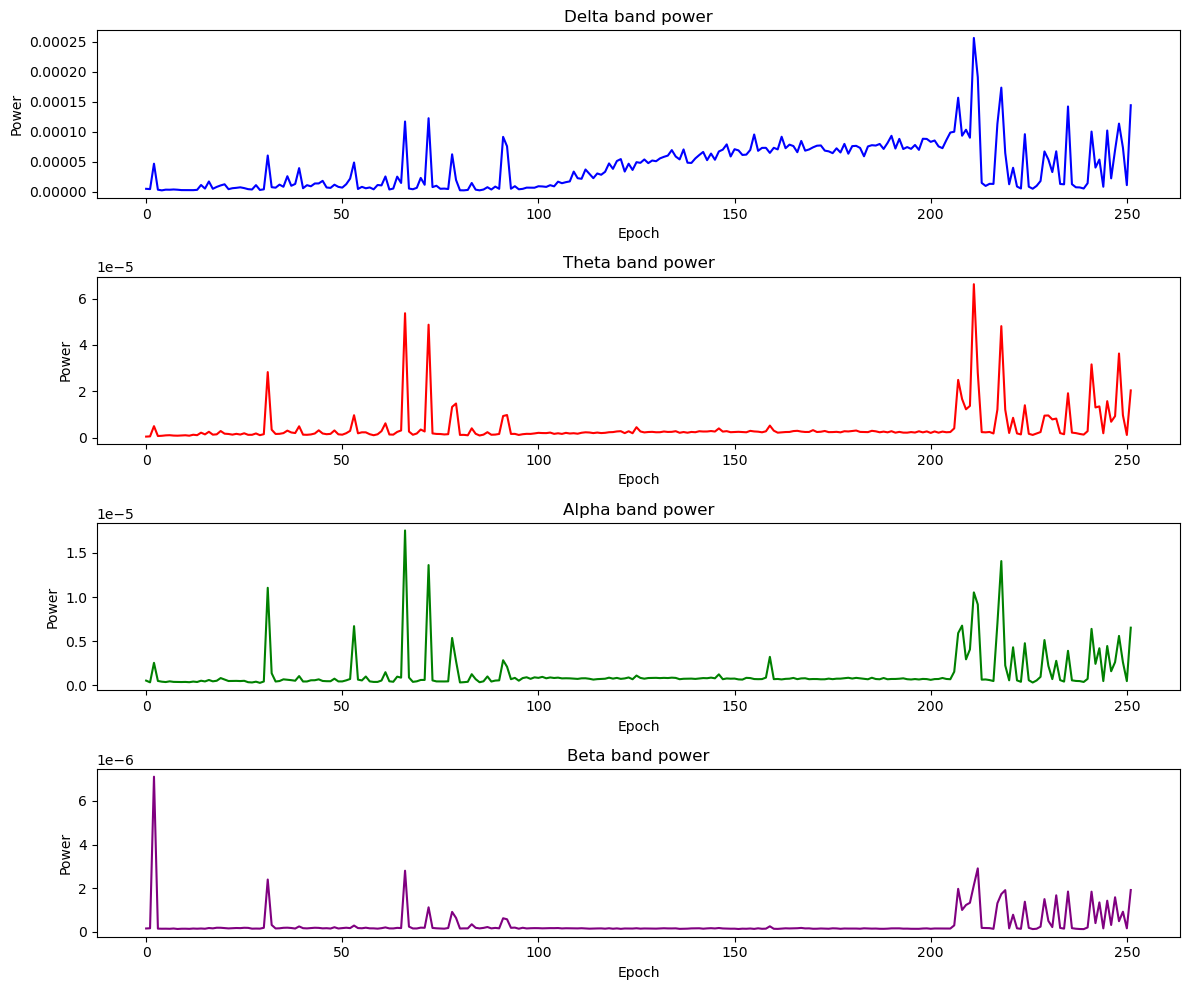

In [33]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10))
colors = ['blue', 'red', 'green', 'purple']

for ax, band, color in zip(axes, bands.keys(), colors):
    ax.plot(df[band], color=color)
    ax.set_title(f'{band.capitalize()} band power')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Power')

plt.tight_layout()
plt.show()

### Now we classify the sleep stages

In [37]:
# calculate thresholds based on each band's own distribution
delta_thresh = df['delta_rel'].median() + 0.5 * df['delta_rel'].std()
theta_thresh = df['theta_rel'].median()
alpha_thresh = df['alpha_rel'].median()
beta_thresh = df['beta_rel'].median()

def classify_threshold(row):
    # N3 - delta is significantly above its own normal level
    if row['delta_rel'] > delta_thresh and row['delta_rel'] > 0.5:
        return 'N3'
    # Wake - beta or alpha is relatively elevated
    elif row['beta_rel'] > beta_thresh and row['alpha_rel'] > alpha_thresh:
        return 'Wake'
    # REM - alpha elevated, delta low
    elif row['alpha_rel'] > alpha_thresh and row['delta_rel'] < delta_thresh:
        return 'REM'
    # N1/N2 - theta elevated, delta moderate
    elif row['theta_rel'] > theta_thresh:
        return 'N1/N2'
    else:
        return 'N3'

df['sleep_stage'] = df.apply(classify_threshold, axis=1)
print(df['sleep_stage'].value_counts())

sleep_stage
N3       113
Wake     112
REM       14
N1/N2     13
Name: count, dtype: int64


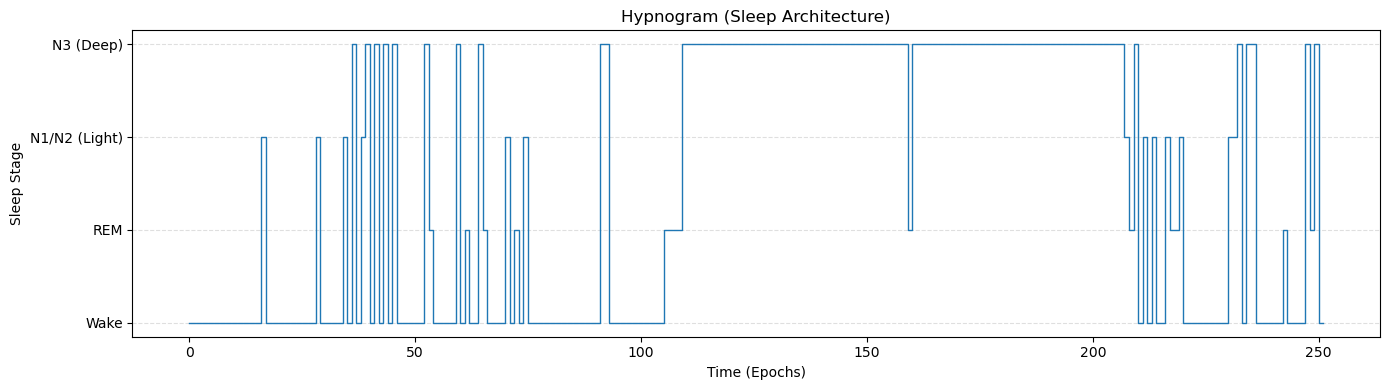

In [44]:
plt.figure(figsize=(14, 4))

# Step plot (important)
plt.step(range(len(df)), df['stage_num'], where='post', linewidth=1)

# Invert y-axis (sleep labs do this)
plt.gca().invert_yaxis()

# Labels
plt.yticks([1, 2, 3, 4], ['N3 (Deep)', 'N1/N2 (Light)', 'REM', 'Wake'])
plt.xlabel('Time (Epochs)')
plt.ylabel('Sleep Stage')

# Title
plt.title('Hypnogram (Sleep Architecture)')

# Grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()